# Import

In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Domain & Period

In [2]:
iyear=1960
fyear=2025
dom='HMA'

In [3]:
#load vimd
vimd = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/vimd_monthly_era5_1940-2025_NH_025x025.nc')
vimd = vimd.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

In [4]:
#focus on High Mountain Asia (HMA)
vimd_MA = field_dom(vimd,dom)

# Annual Mean

In [5]:
vimd_mean = vimd_MA['vimd'].mean(dim='valid_time')

10


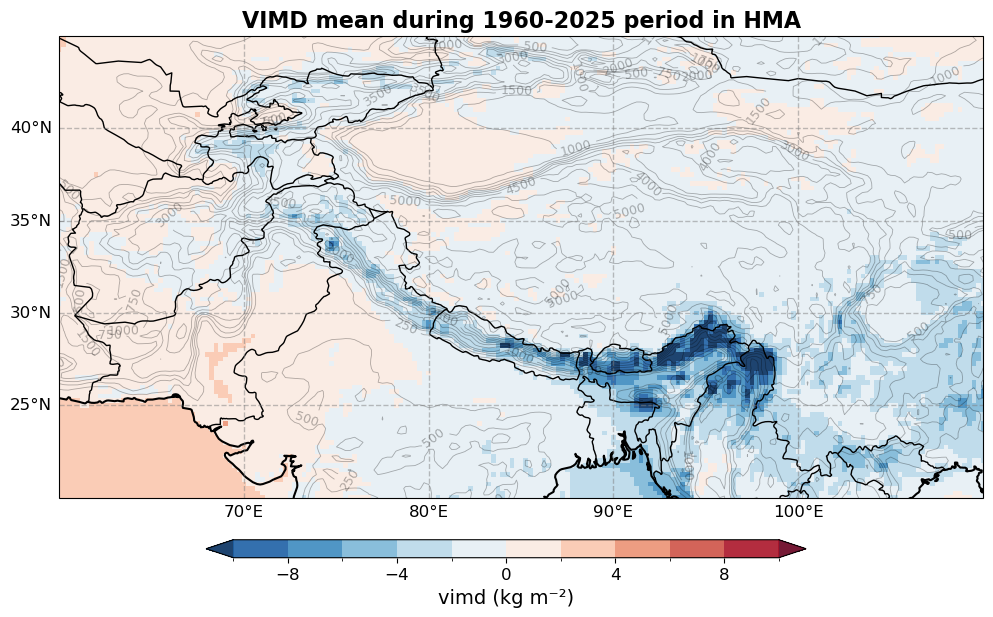

In [16]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#vimd color definition
step = 2
vmax = 10
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

pcm = ax.pcolormesh(
    vimd_mean['longitude'], vimd_mean['latitude'], vimd_mean,
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree(), alpha=0.9)

#Map limitations
ax.set_extent([
    float(vimd_mean.longitude.min()),
    float(vimd_mean.longitude.max()),
    float(vimd_mean.latitude.min()),
    float(vimd_mean.latitude.max())
], crs=ccrs.PlateCarree())

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Legends
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("vimd (kg m⁻²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.set_title(f"VIMD mean during {iyear}-{fyear} period in {dom}", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_vimd_era5/"
#plotname=f'vimd_mean_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Climatology of vimd

In [17]:
#Group by month + mean
monthly_clim = vimd_MA.groupby('valid_time.month').mean('valid_time')['vimd']

30


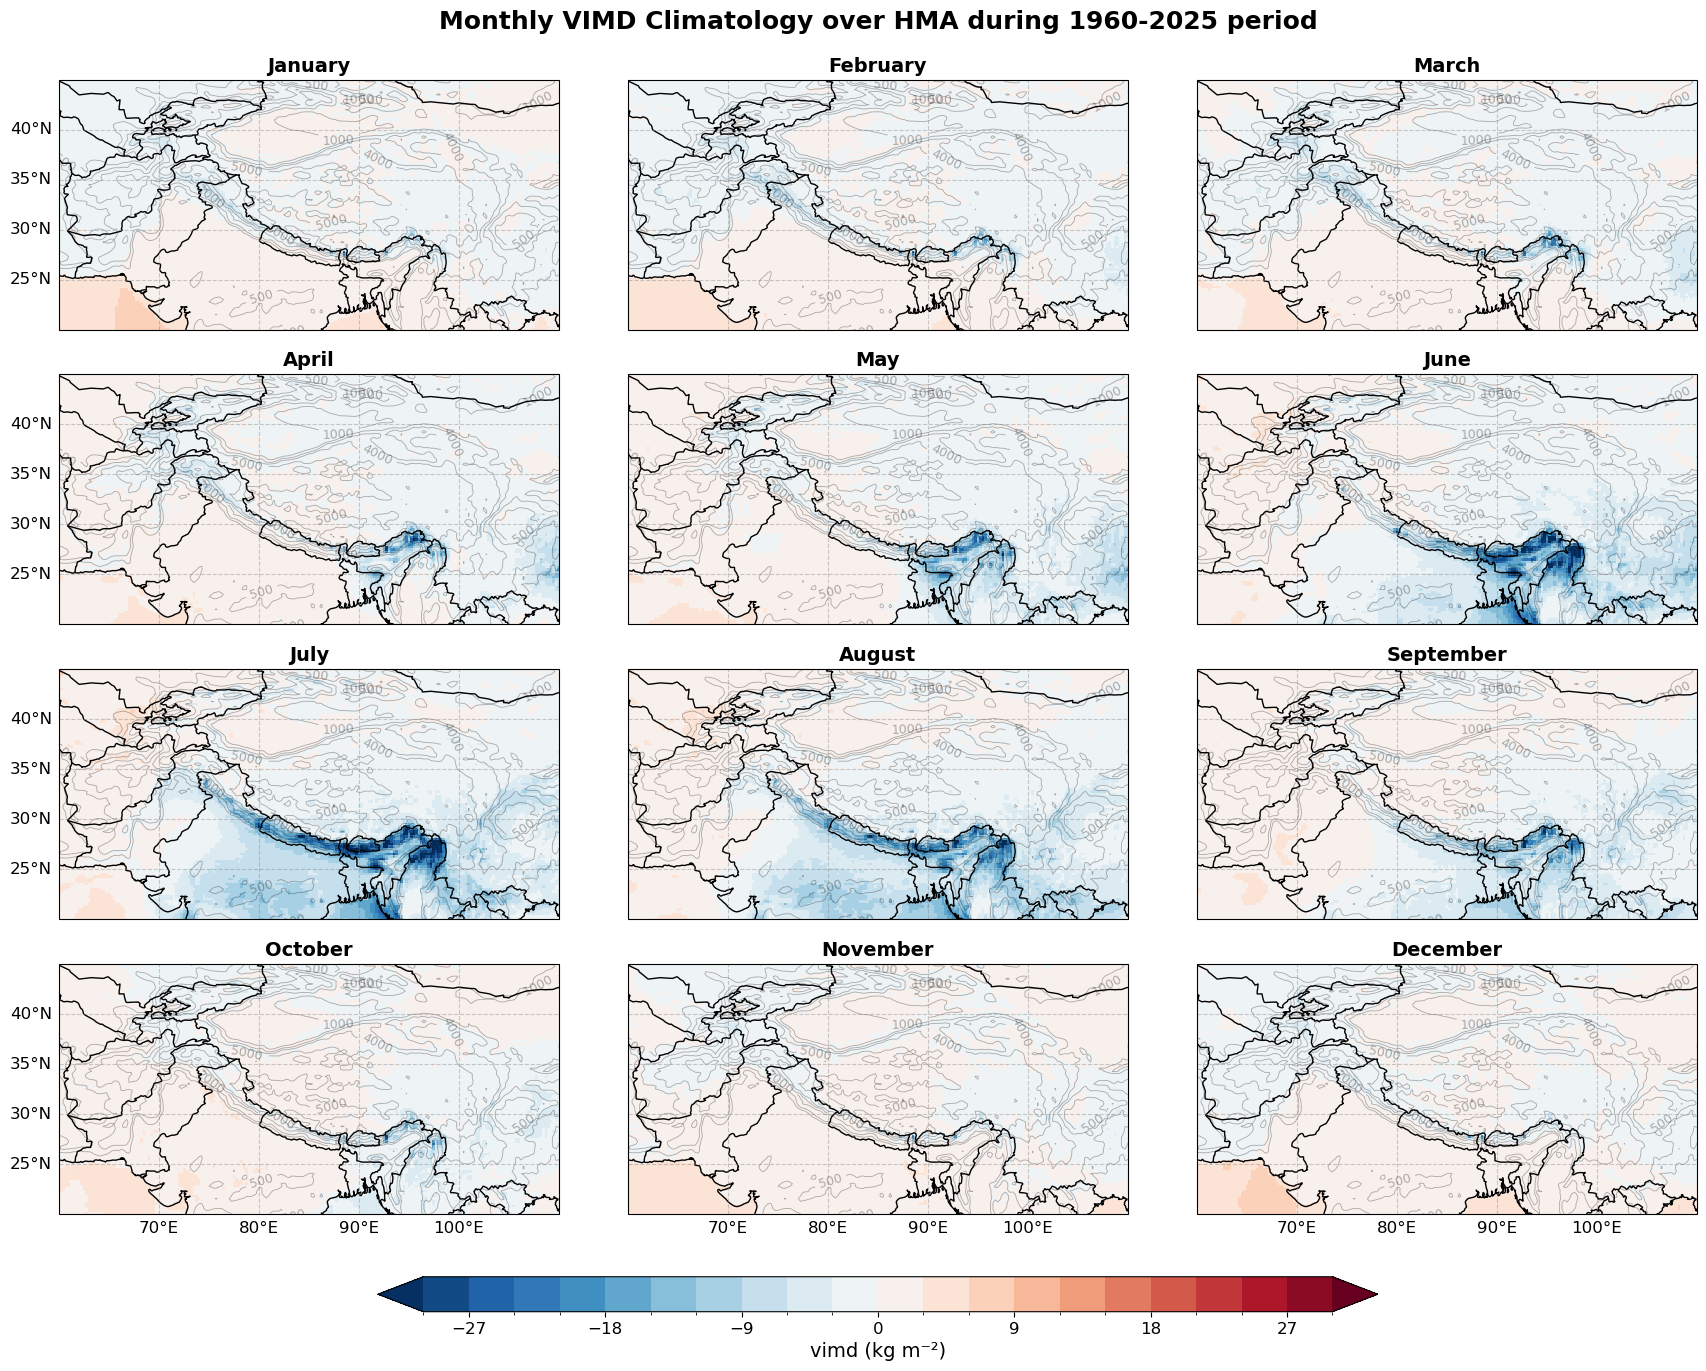

In [23]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

step = 3
vmax = 30
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(4, 3,figsize=(20, 14),subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    data_month = monthly_clim.sel(month=i+1)
    im = ax.pcolormesh(data_month.longitude,data_month.latitude,data_month,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(vimd_mean.longitude.min()),
        float(vimd_mean.longitude.max()),
        float(vimd_mean.latitude.min()),
        float(vimd_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(calendar.month_name[i+1],fontsize=14,weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9)
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("vimd (kg m⁻²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08,right=0.92,top=0.93,bottom=0.12,wspace=0.05,hspace=0.18)
plt.suptitle(f"Monthly VIMD Climatology over {dom} during {iyear}-{fyear} period",fontsize=18,weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_vimd_era5/"
#plotname=f'monthly_vimd_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Climatology of vimd

In [24]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
clim_dict = {}

#Rename time dimension for 'clim' function
vimd_MA = vimd_MA.rename({'valid_time': 'time'})

#Climatology for each season
for season in seasons:
    clim_season = clim(vimd_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    clim_dict[season] = clim_season

20


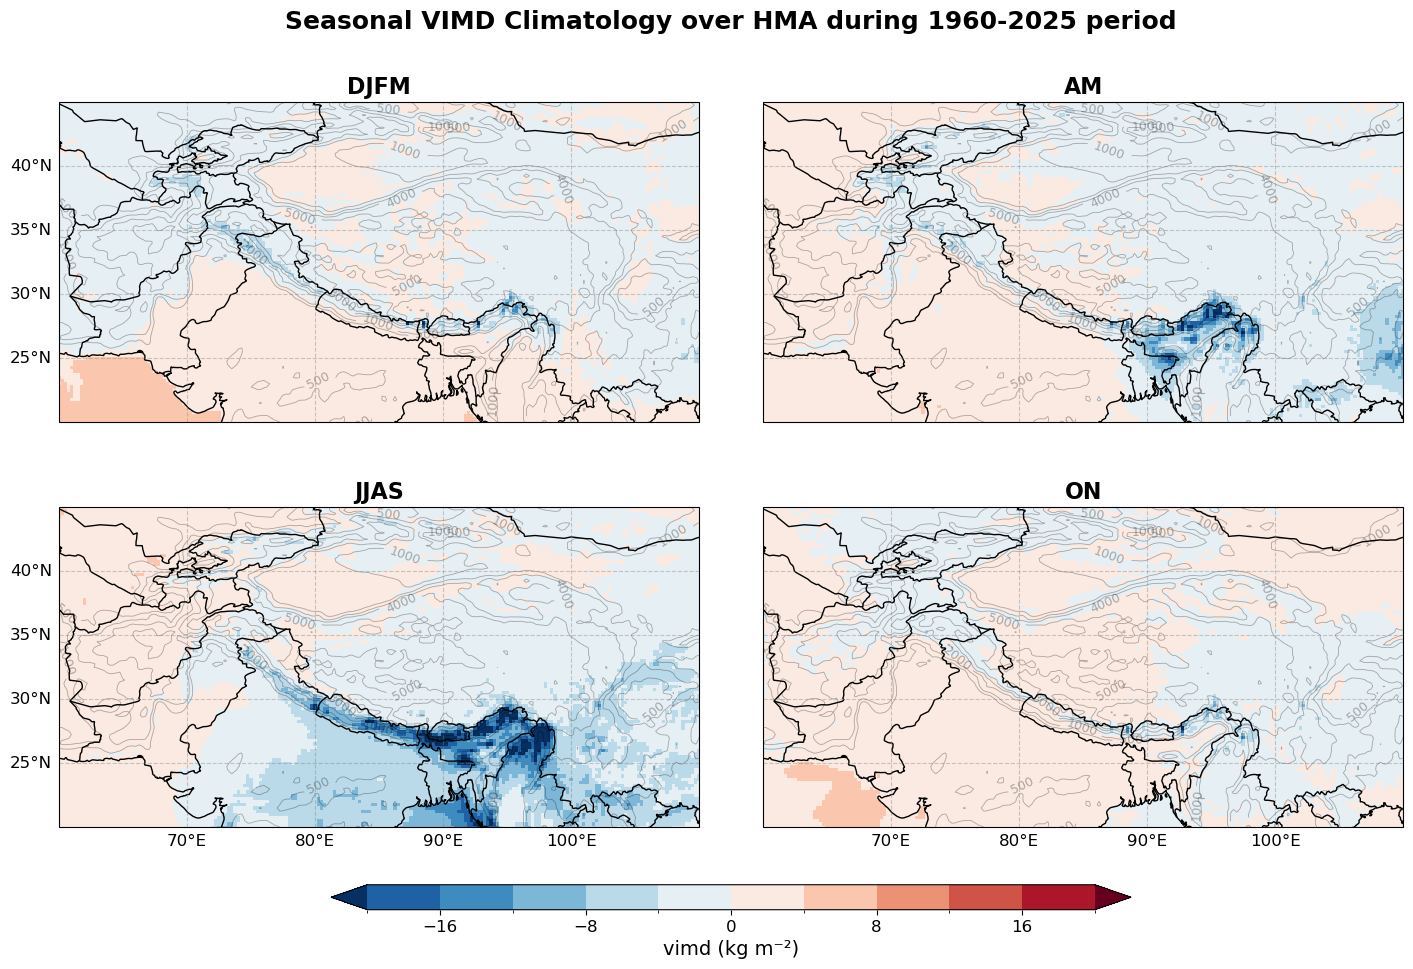

In [27]:
seasons = ["DJFM", "AM", "JJAS", "ON"]

step = 4
vmax = 20
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]['vimd']

    im = ax.pcolormesh(data_season.longitude,data_season.latitude,data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(vimd_mean.longitude.min()),
        float(vimd_mean.longitude.max()),
        float(vimd_mean.latitude.min()),
        float(vimd_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("vimd (kg m⁻²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal VIMD Climatology over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_vimd_era5/"
#plotname=f'seasonal_vimd_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

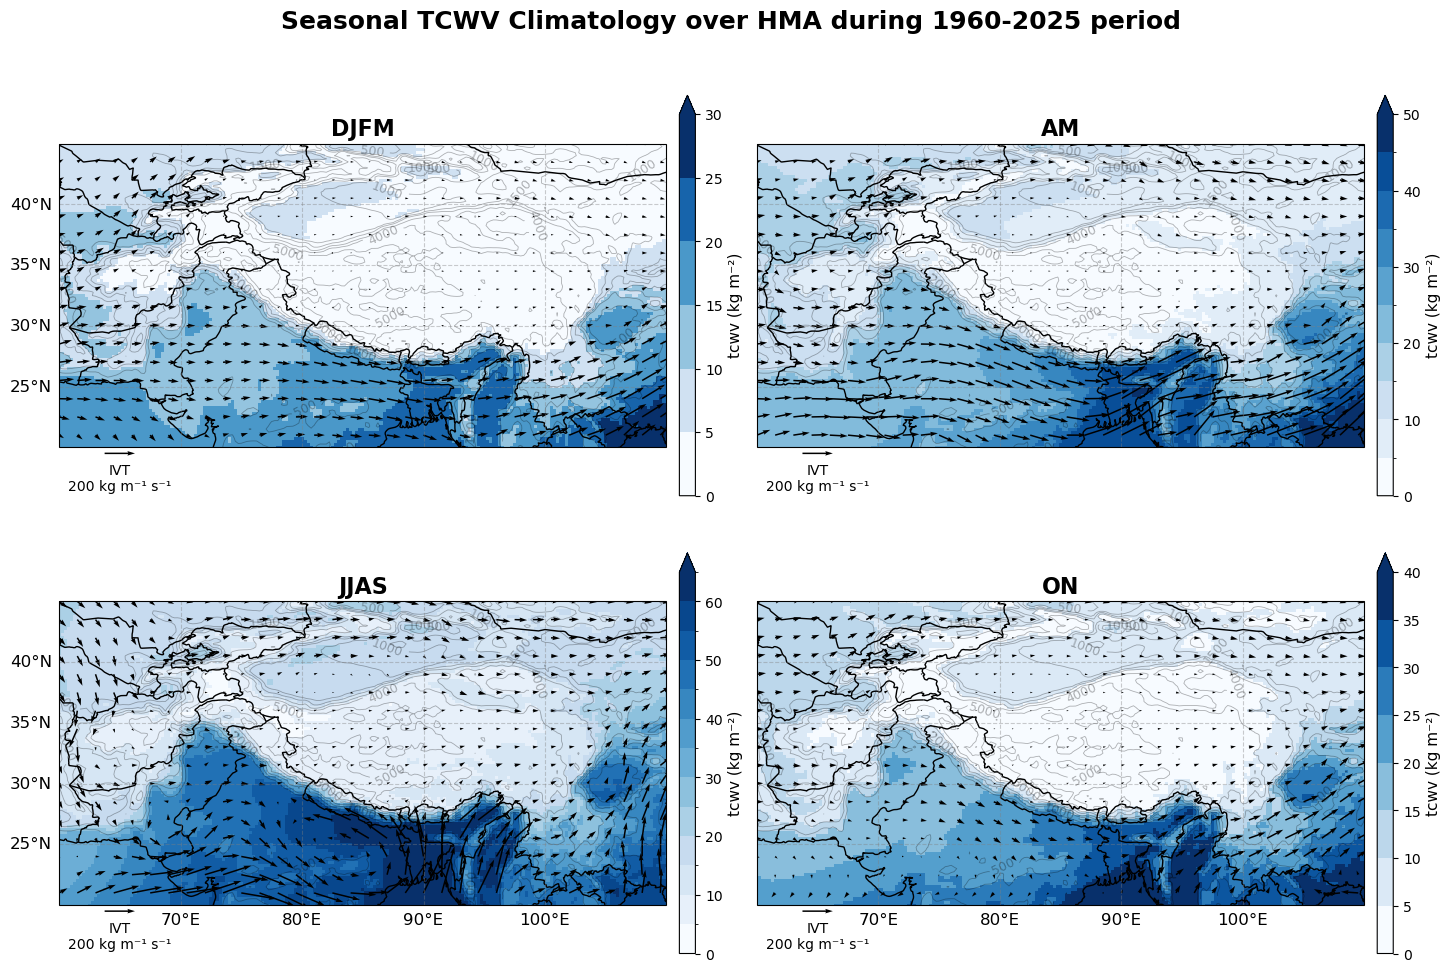

In [13]:
#==============  Colorbar for each season  ===============================

seasons = ["DJFM", "AM", "JJAS", "ON"]

vmin_dict = 0


elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]['tcwv']

    vmin = vmin_dict
    #vmax = vmax_dict[season]
    vmax = float(data_season.max())
    levels = np.arange(vmin, vmax, 5)
    cmap = plt.get_cmap("Blues")
    norm = mcolors.BoundaryNorm(levels, cmap.N)
    
    im = ax.pcolormesh(data_season.longitude,data_season.latitude,data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())

    #IVT Vectors
    step = 6
    u_plot = u_clim_dict[season]["viwve"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step))
    v_plot = v_clim_dict[season]["viwvn"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step))
    q = ax.quiver(u_plot.longitude,u_plot.latitude,u_plot,v_plot,transform=ccrs.PlateCarree(),scale=scale_ivt_dict[season],width=0.0025,headwidth=3
             ,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.7, fraction=0.04, aspect=25, extend='max')
    cbar.set_label("tcwv (kg m⁻²)", fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    ax.quiverkey(q,0.1, -0.02, 200,"IVT\n200 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes')

fig.subplots_adjust(left=0.08, right=0.92, top=0.98, bottom=-0.05, wspace=0.08, hspace=-0.2)
plt.suptitle(f"Seasonal TCWV Climatology over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'seasonal_tcwv_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Annual Trend of tcwv

In [18]:
tcwv_annual,_ = seasonal_selection(tcwv_MA['tcwv'], 'JJA', iyear, fyear)
par = trend_vect(tcwv_annual.time,tcwv_annual,dim='time')
trend = par[0]*10;p = par[3]

uivt_annual,_ = seasonal_selection(uivt_MA['viwve'], 'JJA', iyear, fyear)
u_par = trend_vect(uivt_annual.time,uivt_annual,dim='time')
u_trend = u_par[0]*10;u_p = u_par[3]

vivt_annual,_ = seasonal_selection(vivt_MA['viwvn'], 'JJA', iyear, fyear)
v_par = trend_vect(vivt_annual.time,vivt_annual,dim='time')
v_trend = v_par[0]*10;v_p = v_par[3]

1.4


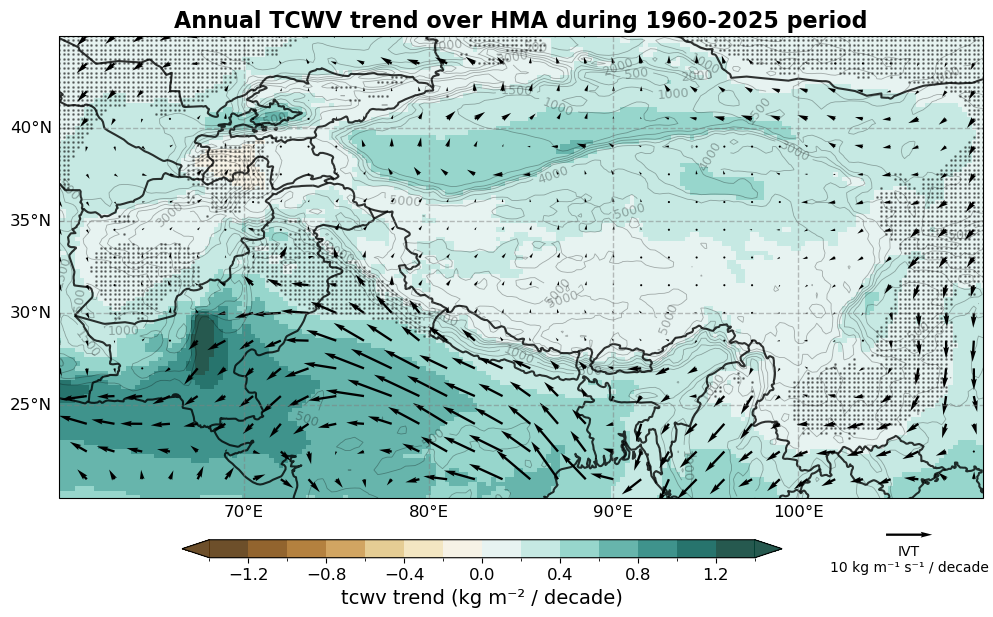

In [21]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

step = 0.2
vmax = 1.4
#vmax = round(float(np.abs(trend.max().values)), 2)
print(vmax)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

pcm = ax.pcolormesh(trend['longitude'],trend['latitude'],trend,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(), alpha=0.85)

#Map limitations
ax.set_extent([
    float(tcwv_mean.longitude.min()),
    float(tcwv_mean.longitude.max()),
    float(tcwv_mean.latitude.min()),
    float(tcwv_mean.latitude.max())
], crs=ccrs.PlateCarree())

sig = p > 0.05   # significativity threshold
step = 1  # for stepping the points on the map that appears. 1 point out of 2 on every direction.
#ax.contourf(trend['longitude'],trend['latitude'],sig,levels=[0.5, 1],hatches=['///'],colors='none',transform=ccrs.PlateCarree())
lon_sig, lat_sig = trend['longitude'].values, trend['latitude'].values
lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
          color='black', s=1, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)

#IVT Vectors
step = 6
u_plot = u_trend[::step, ::step]
v_plot = v_trend[::step, ::step]
q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=200,width=0.0025,headwidth=2.5
             ,rasterized=True)

ax.coastlines(linewidth=1.5, alpha = 0.8)
ax.add_feature(cfeature.BORDERS, linewidth=1.5, alpha = 0.8)

elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,2500,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.23, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("tcwv trend (kg m⁻² / decade)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.92, -0.08, 10,"IVT\n10 kg m⁻¹ s⁻¹ / decade",labelpos='S',coordinates='axes')

ax.set_title(f"Annual TCWV trend over {dom} during {iyear}-{fyear} period", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Trends of tcwv

In [22]:
seasons = [1,2,3,4,5,6,7,8,9,10,11,12]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

u_trend_dict = {}
u_p_dict = {}
v_trend_dict = {}
v_p_dict = {}

#Climatology for each season
for season in seasons:
    tcwv_season,_ = monthly_selection(tcwv_MA['tcwv'], season, start_year, end_year)
    par = trend_vect(tcwv_season.time.dt.year,tcwv_season,dim='time')
    trend_season = par[0];p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

    uivt_season,_ = monthly_selection(uivt_MA['viwve'], season, start_year, end_year)
    u_par = trend_vect(uivt_season.time.dt.year,uivt_season,dim='time')
    u_trend_season = u_par[0];u_p_season = u_par[3]
    u_trend_dict[season] = u_trend_season
    u_p_dict[season] = u_p_season

    vivt_season,_ = monthly_selection(vivt_MA['viwvn'], season, start_year, end_year)
    v_par = trend_vect(vivt_season.time.dt.year,vivt_season,dim='time')
    v_trend_season = v_par[0];v_p_season = v_par[3]
    v_trend_dict[season] = v_trend_season
    v_p_dict[season] = v_p_season

0.14


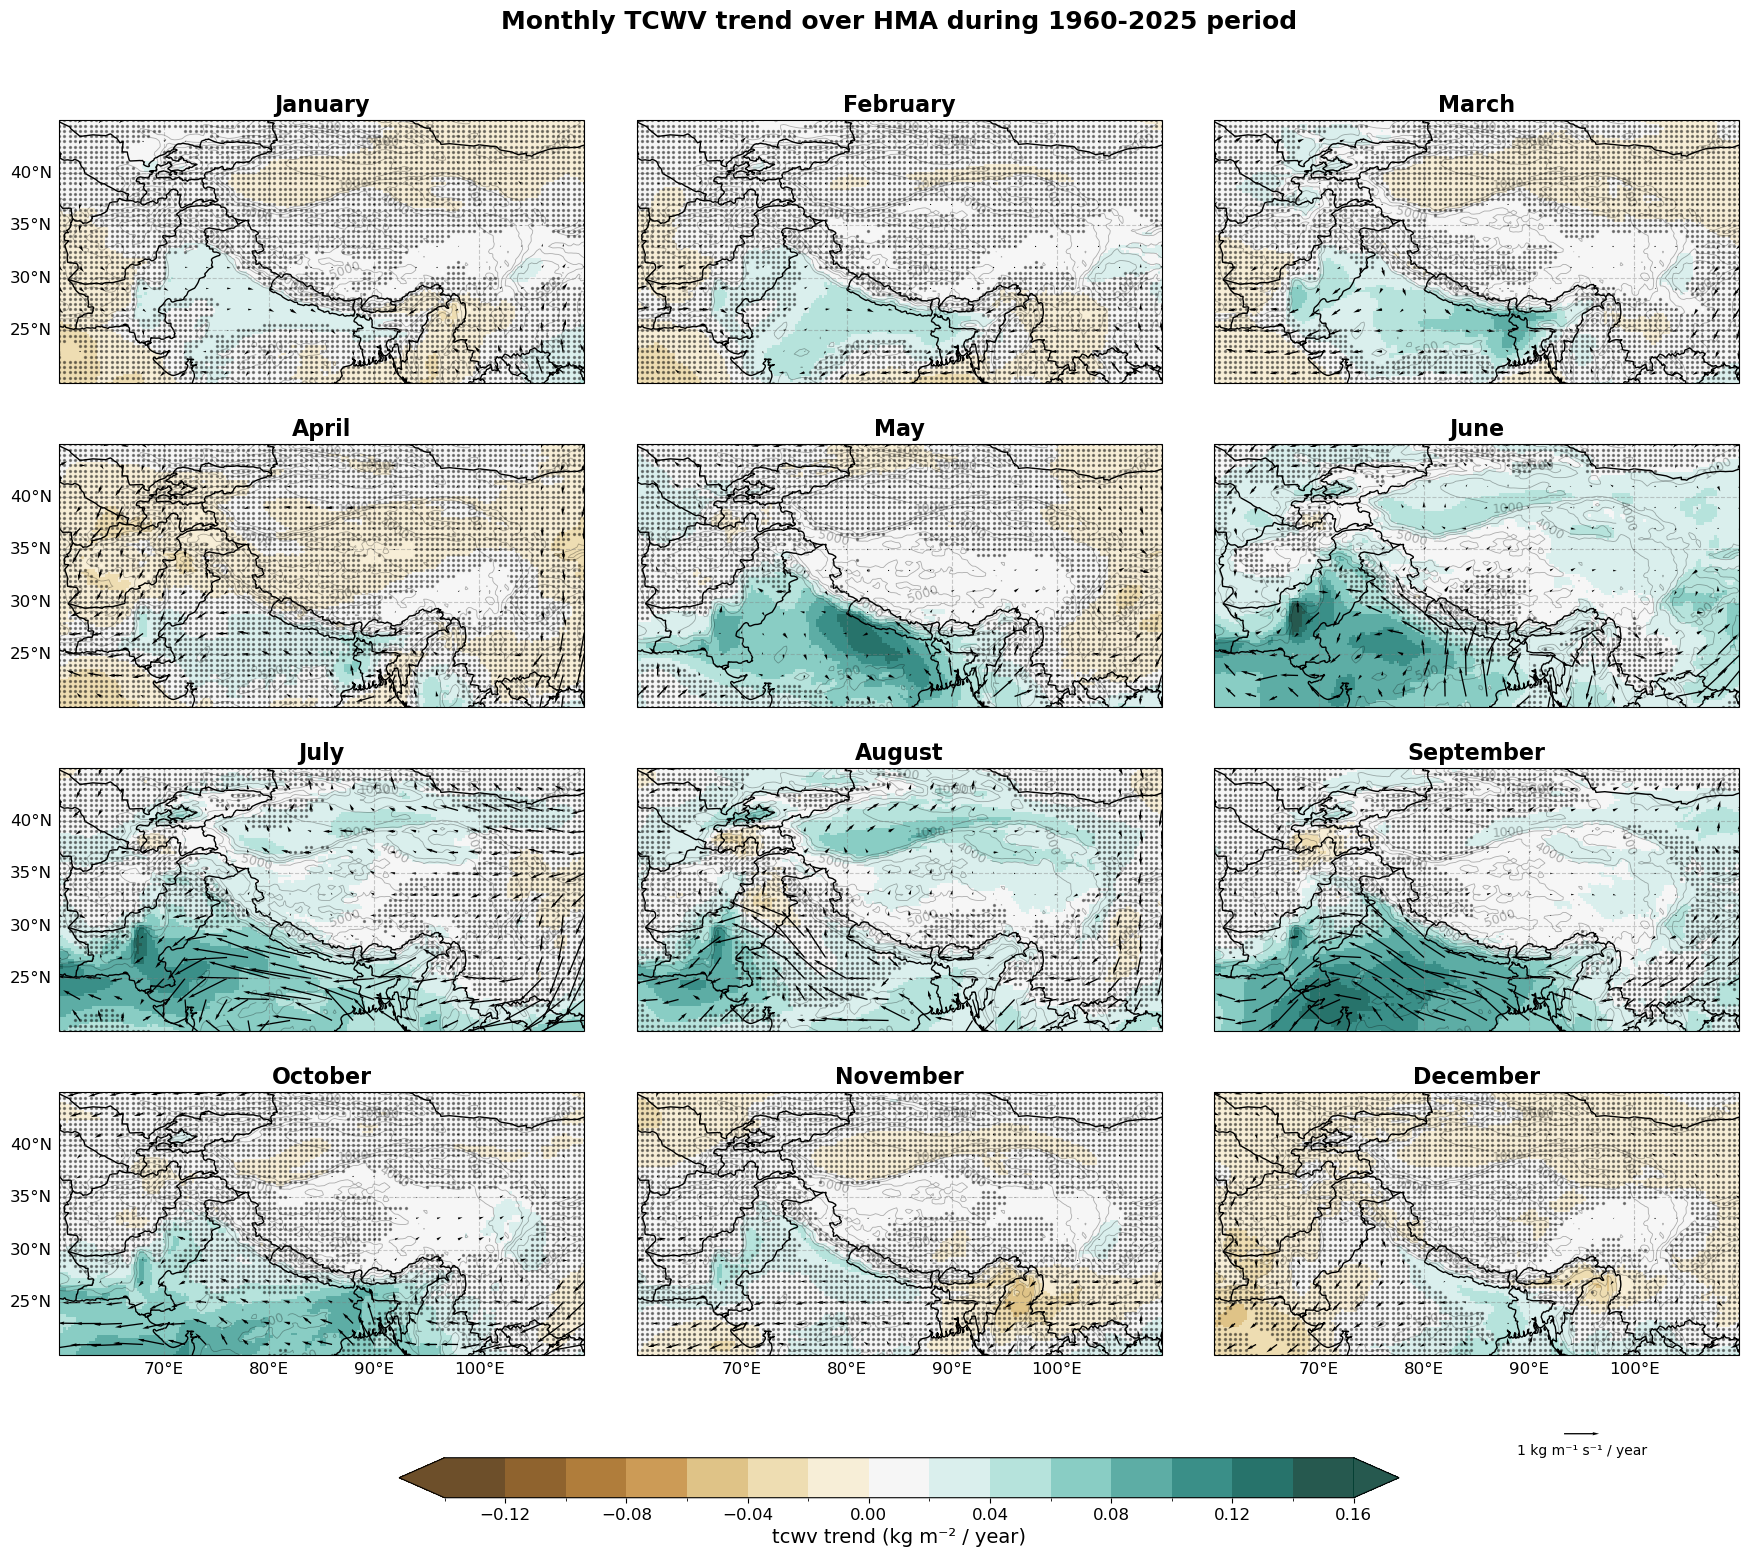

In [23]:
seasons_str = ["January", "February", "March", "April",
                "May", "June", "July", "August",
                "September", "October", "November", "December"]
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

step = 0.02
vmax = 0.14
#vmax = round(max(float(np.abs(ds.max().values)) for ds in trend_dict.values()), 2)
print(vmax)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(4, 3, figsize=(20, 16), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p_dict[season] > 0.05   
    step = 2
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha = 0.4)

    step = 8
    u_plot = u_trend_dict[season][::step, ::step]
    v_plot = v_trend_dict[season][::step, ::step]
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_plot, v_plot,transform=ccrs.PlateCarree(),
                  scale=15,width=0.0025,headwidth=2.5,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(seasons_str[i], fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tcwv trend (kg m⁻² / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.70, -0.3, 1,"1 kg m⁻¹ s⁻¹ / year",labelpos='S',coordinates='axes')


fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Monthly TCWV trend over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Trends of IVT

In [24]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

u_trend_dict = {}
u_p_dict = {}
v_trend_dict = {}
v_p_dict = {}

#Climatology for each season
for season in seasons:
    tcwv_season,_ = seasonal_selection(tcwv_MA['tcwv'], season, start_year, end_year)
    par = trend_vect(tcwv_season.time,tcwv_season,dim='time')
    trend_season = par[0]*10;p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

    uivt_season,_ = seasonal_selection(uivt_MA['viwve'], season, start_year, end_year)
    u_par = trend_vect(uivt_season.time,uivt_season,dim='time')
    u_trend_season = u_par[0]*10;u_p_season = u_par[3]
    u_trend_dict[season] = u_trend_season
    u_p_dict[season] = u_p_season

    vivt_season,_ = seasonal_selection(vivt_MA['viwvn'], season, start_year, end_year)
    v_par = trend_vect(vivt_season.time,vivt_season,dim='time')
    v_trend_season = v_par[0]*10;v_p_season = v_par[3]
    v_trend_dict[season] = v_trend_season
    v_p_dict[season] = v_p_season

(D- 1960  JF- 1961  to D- 2025 JF- 2026
(D- 1960  JF- 1961  to D- 2025 JF- 2026
(D- 1960  JF- 1961  to D- 2025 JF- 2026


1.4


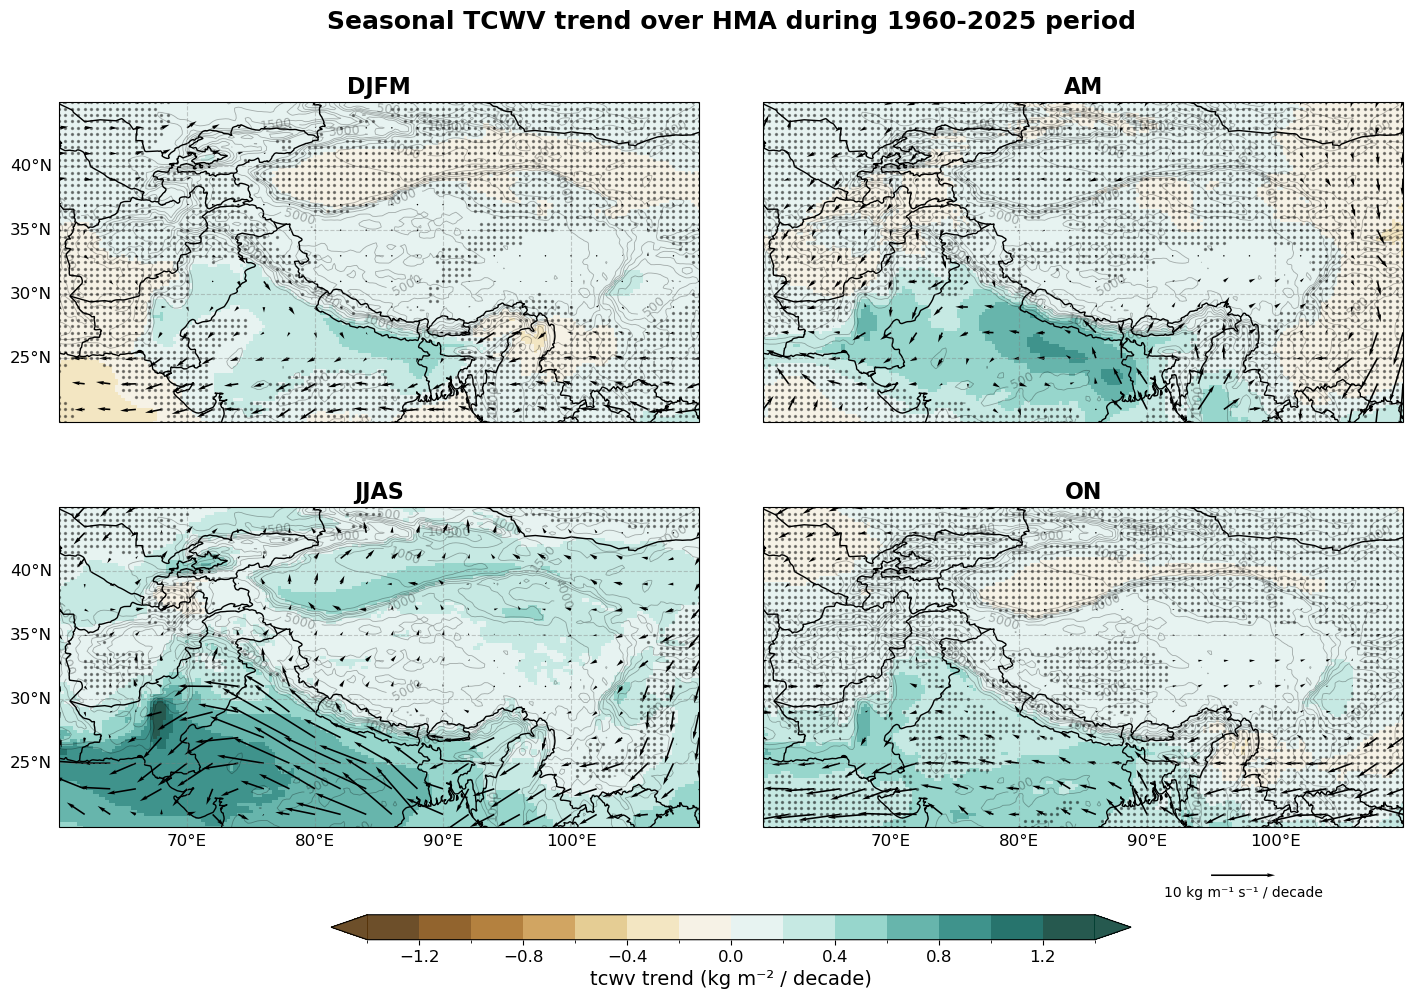

In [25]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
step = 0.2
vmax = 1.4
#vmax = round(max(float(np.abs(ds.max().values)) for ds in trend_dict.values()), 2)
print(vmax)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p_dict[season] > 0.05   
    step = 2
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)

    step = 8
    u_plot = u_trend_dict[season][::step, ::step]
    v_plot = v_trend_dict[season][::step, ::step]
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_plot, v_plot,transform=ccrs.PlateCarree(),
                  scale=100,width=0.0025,headwidth=2.5,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,2500,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tcwv trend (kg m⁻² / decade)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.75, -0.15, 10,"10 kg m⁻¹ s⁻¹ / decade",labelpos='S',coordinates='axes')


fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal TCWV trend over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

## Percentage trend

In [26]:
seasons = ["DJFM","AM","JJAS","ON"]

trend_percentage_dict = {}
u_trend_percentage_dict = {}
v_trend_percentage_dict = {}

for season in seasons:
    trend_percentage_dict[season] = (trend_dict[season] / clim_dict[season]).where(clim_dict[season] != 0) * 100

5


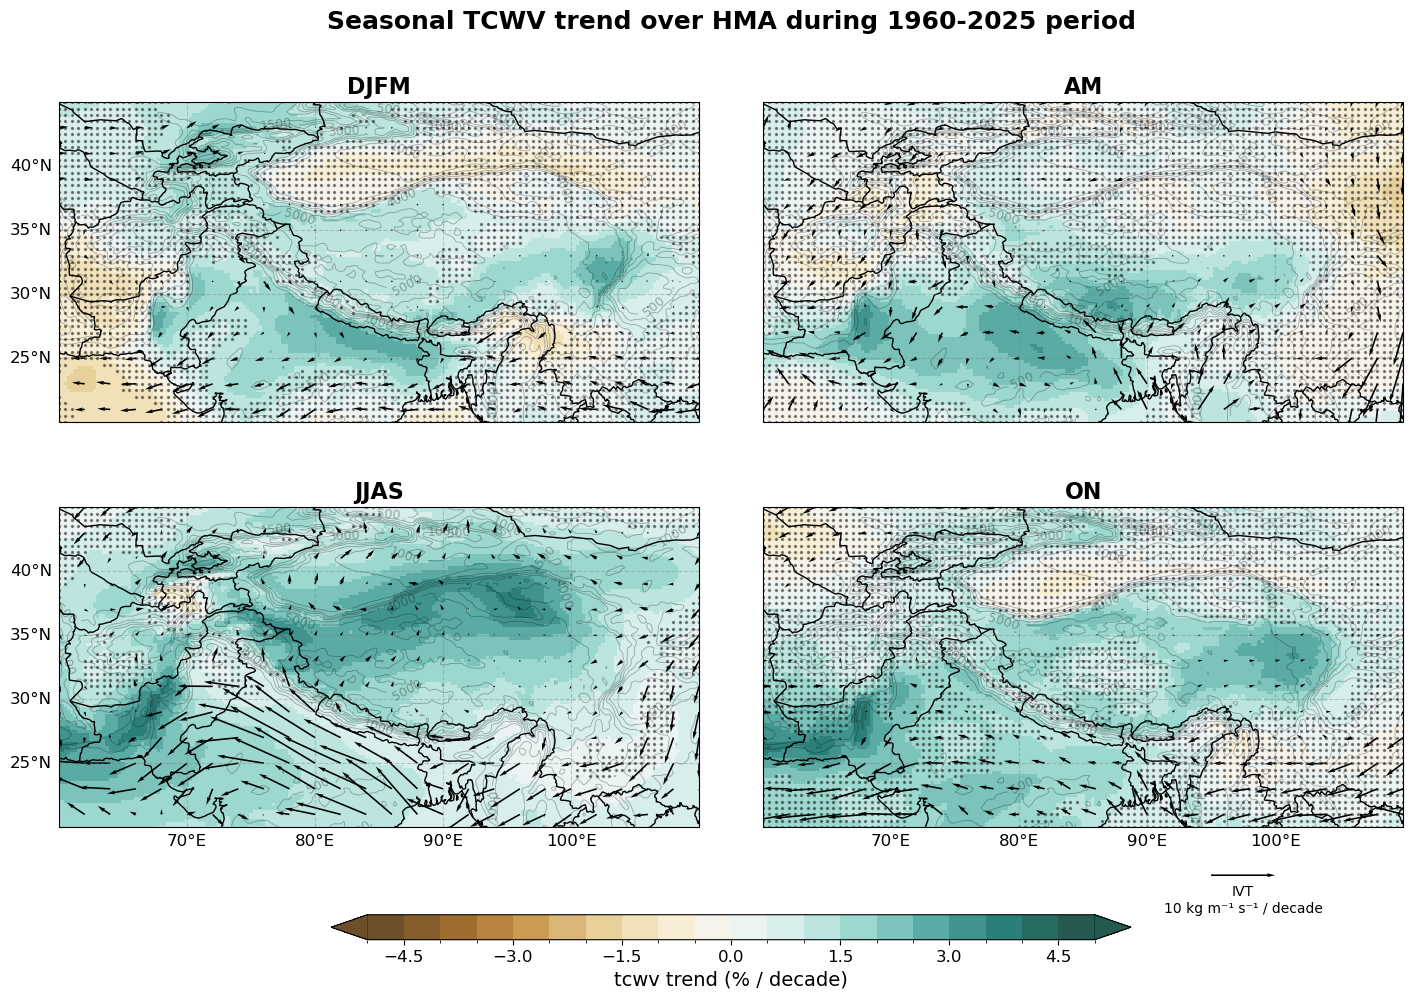

In [37]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
step = 0.5
vmax = 5
#vmax = round(max(float(np.abs(ds.max().values)) for ds in trend_dict.values()), 2)
print(vmax)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_percentage_dict[season]['tcwv']

    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p_dict[season] > 0.05   
    step = 2
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)

    step = 8
    u_plot = u_trend_dict[season][::step, ::step]
    v_plot = v_trend_dict[season][::step, ::step]
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_plot, v_plot,transform=ccrs.PlateCarree(),
                  scale=100,width=0.0025,headwidth=2.5,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,1500,2000,2500,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tcwv trend (% / decade)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.75, -0.15, 10,"IVT\n10 kg m⁻¹ s⁻¹ / decade",labelpos='S',coordinates='axes')


fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal TCWV trend over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()